# German Credit Scores using a Neural Network

## Loading the Packages

In [6]:
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.neural_network import MLPClassifier
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.metrics import classification_report, confusion_matrix, precision_score, accuracy_score
from sklearn.metrics import RocCurveDisplay, roc_curve, roc_auc_score


## Loading the Data

Load the German Credit data set into the environment

In [8]:
df = pd.read_csv("./german_credit.csv")

and let's have a look at the structure

In [120]:
df

,default,account_check_status,duration_in_month,credit_history,purpose,credit_amount,savings,present_employment_since,installment_as_income_perc,sex,...,present_residence_since,property,age,other_installment_plans,housing,credits_this_bank,job,people_under_maintenance,telephone,foreign_worker
0,Not default,< 0 DM,6,critical account/ other credits existing (not ...,domestic appliances,1169,unknown/ no savings account,.. >= 7 years,4,male,...,4,real estate,67,none,own,2,skilled employee / official,1,"yes, registered under the customers name",yes
1,Default,0 <= ... < 200 DM,48,existing credits paid back duly till now,domestic appliances,5951,... < 100 DM,1 <= ... < 4 years,2,female,...,2,real estate,22,none,own,1,skilled employee / official,1,none,yes
2,Not default,no checking account,12,critical account/ other credits existing (not ...,(vacation - does not exist?),2096,... < 100 DM,4 <= ... < 7 years,2,male,...,3,real estate,49,none,own,1,unskilled - resident,2,none,yes
3,Not default,< 0 DM,42,existing credits paid back duly till now,radio/television,7882,... < 100 DM,4 <= ... < 7 years,2,male,...,4,if not A121 : building society savings agreeme...,45,none,for free,1,skilled employee / official,2,none,yes
4,Default,< 0 DM,24,delay in paying off in the past,car (new),4870,... < 100 DM,1 <= ... < 4 years,3,male,...,4,unknown / no property,53,none,for free,2,skilled employee / official,2,none,yes
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
995,Not default,no checking account,12,existing credits paid back duly till now,radio/television,1736,... < 100 DM,4 <= ... < 7 years,3,female,...,4,real estate,31,none,own,1,unskilled - resident,1,none,yes
996,Not default,< 0 DM,30,existing credits paid back duly till now,car (used),3857,... < 100 DM,1 <= ... < 4 years,4,male,...,4,if not A121 : building society savings agreeme...,40,none,own,1,management/ self-employed/ highly qualified em...,1,"yes, registered under the customers name",yes
997,Not default,no checking account,12,existing credits paid back duly till now,domestic appliances,804,... < 100 DM,.. >= 7 years,4,male,...,4,"if not A121/A122 : car or other, not in attrib...",38,none,own,1,skilled employee / official,1,none,yes
998,Default,< 0 DM,45,existing credits paid back duly till now,domestic appliances,1845,... < 100 DM,1 <= ... < 4 years,4,male,...,4,unknown / no property,23,none,for free,1,skilled employee / official,1,"yes, registered under the customers name",yes


## A first look at the Data


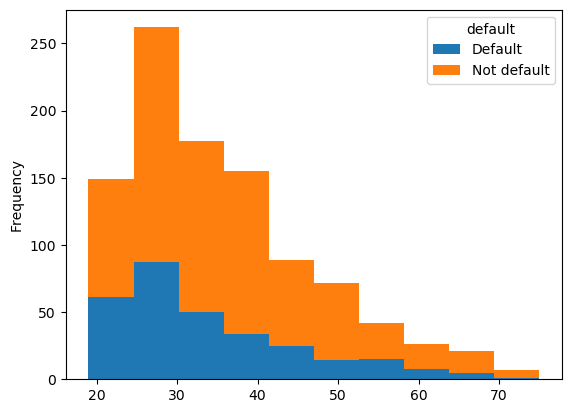

In [ ]:
df.pivot(columns = 'default').age.plot(kind = 'hist', stacked = True) ## that is a stacked histogram

## Prepare the Data

Split the data into 80% to train and 20% to test

In [ ]:
X_train, X_test, Y_train, Y_test = train_test_split(
    df.drop(columns='default'), df['default'],
    test_size=0.2, random_state=0, stratify=df['default']
) #It's dropping the 'default' column to separate the questions from the answers

## Build the pipeline

In [21]:
COLUMN_TYPES = {
    "account_check_status": "category",
    "duration_in_month": "numeric",
    "credit_history": "category",
    "purpose": "category",
    "credit_amount": "numeric",
    "savings": "category",
    "present_employment_since": "category",
    "installment_as_income_perc": "numeric",
    "sex": "category",
    "personal_status": "category",
    "other_debtors": "category",
    "present_residence_since": "numeric",
    "property": "category",
    "age": "category",
    "other_installment_plans": "category",
    "housing": "category",
    "credits_this_bank": "numeric",
    "job": "category",
    "people_under_maintenance": "numeric",
    "telephone": "category",
    "foreign_worker": "category",
}
COLUMNS_TO_SCALE = [key for key in COLUMN_TYPES.keys() if COLUMN_TYPES[key] == "numeric"] # creates a list of all numeric columns
COLUMNS_TO_ENCODE = [key for key in COLUMN_TYPES.keys() if COLUMN_TYPES[key] == "category"] # creates a list of all the "category" columns


In [22]:
"""this part preprocessor:
that automatically applies different rules to different columns."""

numeric_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler()) # scales all the numbers. This is critical for neural networks. It changes all the different scales (like 'Age' 20-80, vs 'Credit Amount' 1000-10000) to a standard scale (centered around 0).
])

categorical_transformer = Pipeline([
    ("imputer", SimpleImputer(strategy="constant", fill_value="missing")),
    ("onehot", OneHotEncoder(handle_unknown="ignore")),
]) 
"""OneHotEncoder processes this column, 
it will delete the original property column and add four new binary columns:"""
![alt text](https://file%2B.vscode-resource.vscode-cdn.net/Users/dongyuangao/Library/CloudStorage/OneDrive-Personal/%E6%96%87%E6%A1%A3/%E5%AD%A6%E4%B8%9A/%E7%A1%95%E5%A3%ABhslu/Lectures%20Lessons%20Subjects/semester%202/Machine%20Learning%201/week5%20ANN/Screenshot%202025-10-23%20at%2010.25.17.png?version%3D1761208095683)

preprocessor = ColumnTransformer(transformers=[
    ("num", numeric_transformer, COLUMNS_TO_SCALE),
    ("cat", categorical_transformer, COLUMNS_TO_ENCODE),
])



zsh:1: bad pattern: [alt


![alt text](https://file%2B.vscode-resource.vscode-cdn.net/Users/dongyuangao/Library/CloudStorage/OneDrive-Personal/%E6%96%87%E6%A1%A3/%E5%AD%A6%E4%B8%9A/%E7%A1%95%E5%A3%ABhslu/Lectures%20Lessons%20Subjects/semester%202/Machine%20Learning%201/week5%20ANN/Screenshot%202025-10-23%20at%2010.25.17.png?version%3D1761208381962)

## Train the model

In [ ]:
pipeline = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("classifier", MLPClassifier(solver='lbfgs', alpha=1e-5, 
    #  This is the scikit-learn name for an Artificial Neural Network (Multi-layer Perceptron)
                    hidden_layer_sizes=(16,), random_state=1))
])

pipeline.fit(X_train, Y_train)
"""It takes your training "questions" (X_train) and training
 "answers" (Y_train) and feeds them into the pipeline. The pipeline automatically:"""

,steps,"[('preprocessor', ...), ('classifier', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('num', ...), ('cat', ...)]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


## Make Predictions

In [24]:
pred_train = pipeline.predict(X_train)
pred_test = pipeline.predict(X_test)


In [25]:
cfm = confusion_matrix(Y_test, pred_test)
print(cfm)

[[ 37  23]
 [ 26 114]]


Calculating the accuracy (never to this manually!)

In [28]:
(cfm[0][0]+cfm[1][1]) / sum(sum(cfm))  #  this is manual

np.float64(0.755)

In [29]:
accuracy_score(Y_test, pred_test)

0.755

and the precision:

In [30]:
cfm[0][0] / (cfm[0][0] + cfm[1][0])

np.float64(0.5873015873015873)

In [31]:
precision_score(Y_test, pred_test, pos_label = 'Default')
 # True Positives / (True Positives + False Positives)

0.5873015873015873

or just look at the full classifcation report

In [ ]:
print(classification_report(Y_test, pred_test))
"""interpretation Default:

Precision (0.59): Of all the times your model predicted "Default", it was only correct 59% of the time. (This is the same as your manual calculation cfm[0][0] / (cfm[0][0] + cfm[1][0]) [cell 130]).

Recall (0.62): Of all the actual "Default" customers in the test set, your model successfully found 62% of them.

f1-score (0.60): The harmonic mean (a type of average) of Precision and Recall. It's a single score that balances both concerns.

Support (60): This is just a count. It tells you there were 60 actual "Default" customers in your test data."""

              precision    recall  f1-score   support

     Default       0.59      0.62      0.60        60
 Not default       0.83      0.81      0.82       140

    accuracy                           0.76       200
   macro avg       0.71      0.72      0.71       200
weighted avg       0.76      0.76      0.76       200



## ROC Curves

The Receiver Operating Characteristic is a useful tool to indicate model quality. For this we plot sensitivity against 1-specificity.

ROC Curve (Receiver Operating Characteristic) is a very common and useful tool for measuring the quality of a binary classification model

In [26]:
pred_test_scores = pipeline.predict_proba(X_test)[:, 0]
auc = 1-roc_auc_score(Y_test, pred_test_scores)

/Users/dongyuangao/Library/CloudStorage/OneDrive-Personal/文档/学业/硕士hslu/Lectures Lessons Subjects/semester 2/Machine Learning 1/week5 ANN/.venv/lib/python3.13/site-packages/sklearn/utils/_plotting.py:379: FutureWarning: `estimator_name` is deprecated in 1.7 and will be removed in 1.9. Use `name` instead.
  warnings.warn(


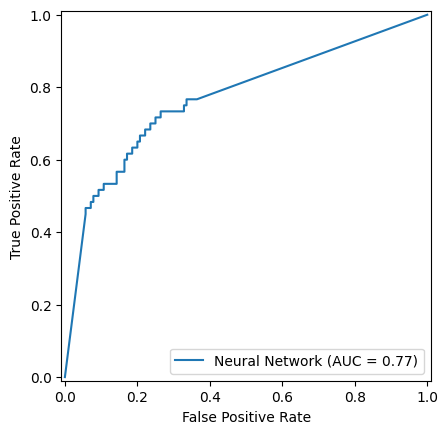

In [ ]:
fpr, tpr, thresholds = roc_curve(Y_test, pred_test_scores, pos_label = 'Default')
display = RocCurveDisplay(fpr=fpr, tpr=tpr, roc_auc = auc, estimator_name = 'Neural Network')
display.plot()
"""AUC = 0.77 (The Score):
AUC stands for Area Under the Curve. 
It's a single number that summarizes the entire plot.
1.0 would be a perfect model.
0.5 would be a useless model (a coin flip).
0.77 indicates that your model has a good (or decent) level of "separability". 
It means there's a 77% chance that the model will correctly rank a randomly chosen "Default" customer higher than a randomly chosen "Not default" customer."""

we can tweak the inputs:
The "inputs" you are changing are:

hidden_layer_sizes: This is the main one. It defines the network's architecture. Your Lab 1 used (16,) (one layer of 16 neurons) [cell 125]. Your Lab 3 tests [2, 5, 10] to see which number of neurons works best [cell 9].

activation: This changes the activation function inside the neurons [cell 9]. Your lecture slides showed these options, like "relu", "tanh", and "logistic" (Sigmoid) .

alpha: This is a training parameter (specifically, a regularization term) that helps prevent overfitting [cell 9].